# Prep for Norman Sciplex

In [1]:
import warnings
import os
import sys
import gc
import warnings

In [21]:
import anndata as ad
import scanpy as sc
import scanpy.external as sce
import copy
import torch
from pathlib import Path
import networkx as nx
from sklearn.neighbors import kneighbors_graph
import numpy as np
import rapids_singlecell as rsc
import scanpy as sc
import cupyx as cpx
import pandas as pd
import numpy as np
import scipy.stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import scib
import scib_metrics
import palantir
import scvi

sys.path.append("/home/icb/kemal.inecik/work/codes/tardis")
import tardis
tardis.config = tardis.config_server

sc.settings.verbosity = 3

print(f"CUDA used: {torch.cuda.is_available()}")

CUDA used: False


In [3]:
%matplotlib inline
%config InlineBackend.figure_format='retina'
import matplotlib.pyplot as plt
import seaborn as sns

import pickle
_rcparams_path = "/home/icb/kemal.inecik/work/codes/tardis/training/local/figures/rcparams.pickle"
with open(_rcparams_path, 'rb') as file:
    _rcparams = pickle.load(file)
plt.rcParams.update(_rcparams)

/home/icb/kemal.inecik/tools/apps/mamba/envs/tardis_env/lib/python3.10/site-packages/matplotlib_inline/config.py:68: DeprecationWarning: InlineBackend._figure_format_changed is deprecated in traitlets 4.1: use @observe and @unobserve instead.
  def _figure_format_changed(self, name, old, new):


In [18]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    adata_file_path = os.path.join(tardis.config.io_directories["processed"], "cpa_GSM_new.h5ad")
    assert os.path.isfile(adata_file_path), f"File not already exist: `{adata_file_path}`"
    adata = ad.read_h5ad(adata_file_path)
    adata.X = adata.layers["counts"].copy()
    del adata.layers
    adata.obs.loc[adata.obs["dose"] == "0.0", "dose_val"] = 0.0
    d = {i: ind for ind, i in enumerate(sorted(adata.obs["dose"].astype(float).unique()))}
    adata.obs["dose_training"] = [d[float(i)] for i in adata.obs["dose"]]
    del adata.obsm, adata.varm, adata.obsp
    del adata.uns["umap"]
    gc.collect()

In [19]:
adata.obs.value_counts(["dose_training", "dose", "dose_val"])

dose_training  dose   dose_val
3              1.0    0.010       2171
0              0.0    0.000       2155
1              0.1    0.001       1961
5              10.0   0.100       1940
2              0.5    0.005       1792
4              5.0    0.050       1790
6              50.0   0.500       1767
7              100.0  1.000       1235
dtype: int64

In [23]:
adata

AnnData object with n_obs × n_vars = 14811 × 4999
    obs: 'sample', 'size_factor', 'n.umi', 'hash_umis', 'pval', 'qval', 'top_to_second_best_ratio', 'top_oligo', 'drug', 'dose', 'vehicle', 'n_counts', 'log_counts', 'n_genes', 'mt_frac', 'product_dose', 'louvain', 'dose_val', 'cell_type', 'drug_dose_name', 'cov_drug_dose_name', 'condition', 'control', 'split', 'dose_training'
    var: 'id', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'dose_colors', 'drug_colors', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'product_dose_colors', 'rank_genes_groups_cov', 'vehicle_colors'

## Models

In [29]:
# Train scVI
scvi.model.SCVI.setup_anndata(adata, layer=None)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    model_params = dict(
        n_latent=24, 
        gene_likelihood = "nb",
    )
    scvi_model = scvi.model.SCVI(adata, **model_params)
    
    train_params = dict(
        train_size=0.8,
        batch_size=512,
        max_epochs=400,
    )
    scvi_model.train(**train_params)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
SLURM auto-requeueing enabled. Setting signal handlers.


Epoch 400/400: 100%|██████████████████████████████████████████████████████████████████████████████████████| 400/400 [09:35<00:00,  1.41s/it, v_num=1, train_loss_step=2.02e+3, train_loss_epoch=1.99e+3]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████████████████████████████████████████████████████████████████████████████████| 400/400 [09:35<00:00,  1.44s/it, v_num=1, train_loss_step=2.02e+3, train_loss_epoch=1.99e+3]


In [30]:
# scVI latent
adata.obsm["scvi"] = scvi_model.get_latent_representation()

In [31]:
# Latent of TarDis model from TarDis paper
dir_path = os.path.join(
    tardis.config.io_directories["models"],
    "cpa_sciplex_v2_encode"
)
tardis_model = tardis.MyModel.load(dir_path, adata=adata)
adata.obsm["tardis"] = tardis_model.get_latent_representation()

INFO     File /lustre/groups/ml01/workspace/kemal.inecik/tardis_data/models/cpa_sciplex_v2_encode/model.pt already 
         downloaded                                                                                                


In [32]:
# PCA 
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e6)
sc.pp.log1p(adata)
sc.pp.pca(adata)

normalizing counts per cell
    finished (0:00:00)
computing PCA
    on highly variable genes
    with n_comps=50
    finished (0:00:14)


In [52]:
working_dir = "/lustre/groups/ml01/workspace/kemal.inecik/sctram_data"
file_name = "norman_sciplex_cpa.h5ad"
adata.write_h5ad(os.path.join(working_dir, file_name))

In [53]:
adata

AnnData object with n_obs × n_vars = 14811 × 4999
    obs: 'sample', 'size_factor', 'n.umi', 'hash_umis', 'pval', 'qval', 'top_to_second_best_ratio', 'top_oligo', 'drug', 'dose', 'vehicle', 'n_counts', 'log_counts', 'n_genes', 'mt_frac', 'product_dose', 'louvain', 'dose_val', 'cell_type', 'drug_dose_name', 'cov_drug_dose_name', 'condition', 'control', 'split', 'dose_training', '_scvi_batch', '_scvi_labels'
    var: 'id', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'dose_colors', 'drug_colors', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'product_dose_colors', 'rank_genes_groups_cov', 'vehicle_colors', '_scvi_uuid', '_scvi_manager_uuid', 'log1p'
    obsm: 'scvi', '_scvi_disentanglement_target', '_scvi_metrics_helper', 'tardis', 'X_pca'
    varm: 'PCs'
    layers: 'counts'

## Calculate latent

In [34]:
latent_scvi = ad.AnnData(X=adata.obsm["scvi"], obs=adata.obs.copy())
latent_tardis = ad.AnnData(X=adata.obsm["tardis"], obs=adata.obs.copy())
latent_pca = ad.AnnData(X=adata.obsm["X_pca"], obs=adata.obs.copy())

In [35]:
sc.pp.neighbors(latent_scvi)
sc.tl.umap(latent_scvi)

computing neighbors
    using data matrix X directly
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:01)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:10)


In [36]:
sc.pp.neighbors(latent_pca)
sc.tl.umap(latent_pca)

computing neighbors
    using data matrix X directly
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:01)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:08)


In [37]:
sc.pp.neighbors(latent_tardis)
sc.tl.umap(latent_tardis)

computing neighbors
    using data matrix X directly
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:01)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:08)


## Visualization

/home/icb/kemal.inecik/tools/apps/mamba/envs/tardis_env/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:371: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  ax.scatter(
/home/icb/kemal.inecik/tools/apps/mamba/envs/tardis_env/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:381: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  ax.scatter(


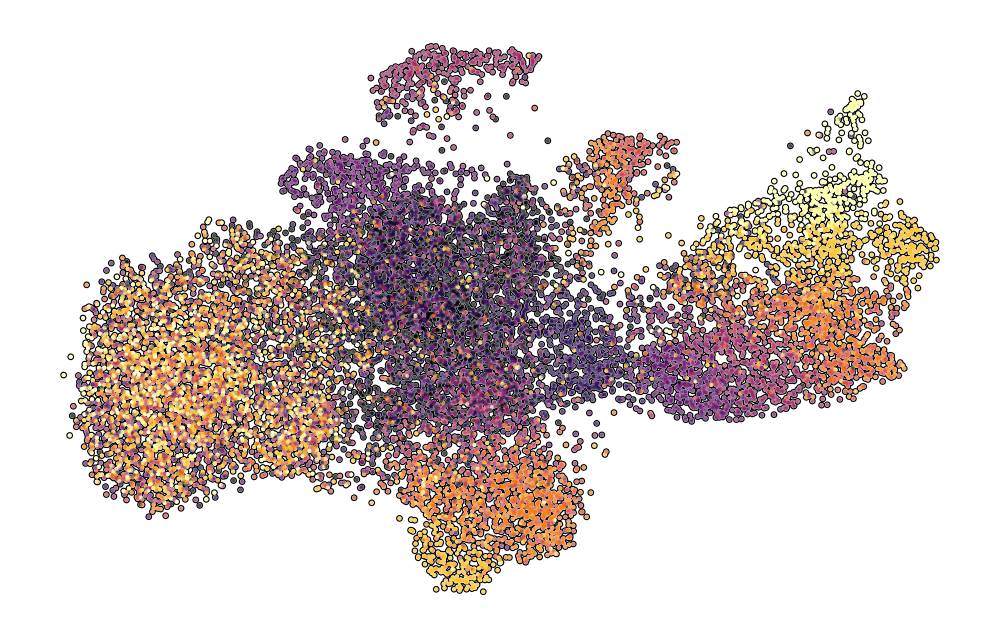

/home/icb/kemal.inecik/tools/apps/mamba/envs/tardis_env/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:371: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
/home/icb/kemal.inecik/tools/apps/mamba/envs/tardis_env/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:381: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
/home/icb/kemal.inecik/tools/apps/mamba/envs/tardis_env/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


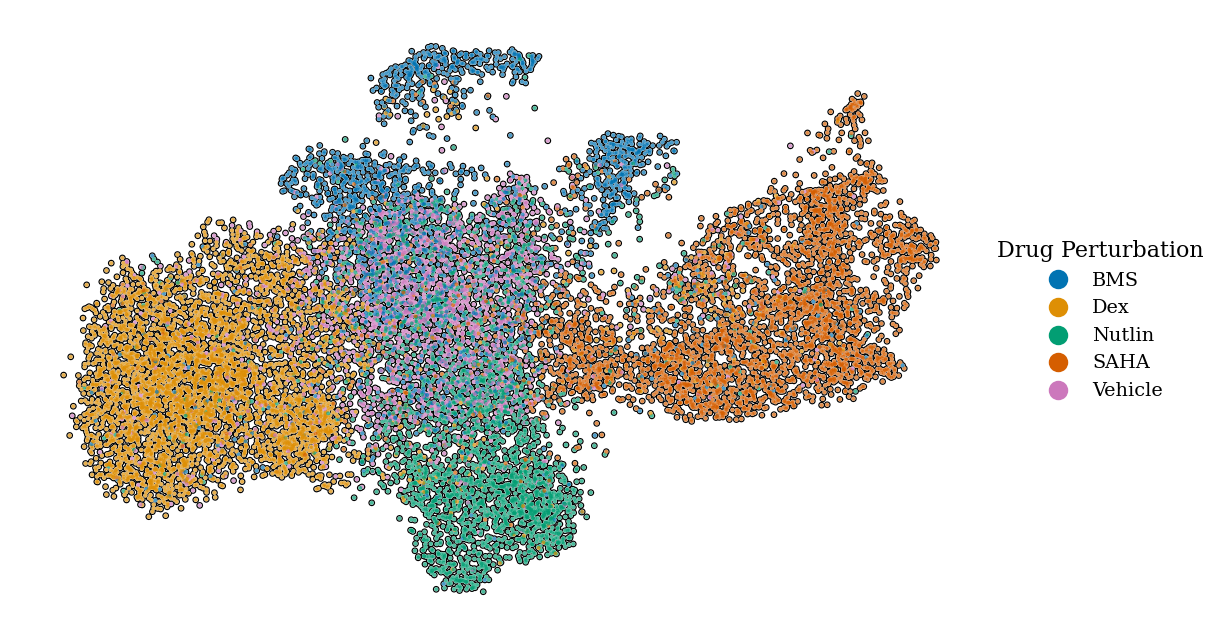

In [48]:
figsize = (8, 5)
fig = plt.figure(figsize=(figsize[0] * 3, figsize[1] * 3))
fig.subplots_adjust(left=0.4, right=0.6, top=0.6, bottom=0.4)

sc.pl.umap(
    latent_scvi,
    color="dose_training",
    ncols=2,
    frameon=False,
    legend_fontsize="x-small",
    show=False,
    ax=plt.gca(),
    color_map="inferno",
    title="",
    # legend_loc="on data",
    # legend_fontweight="semibold",
    # legend_fontoutline=2,
    add_outline=True,
    colorbar_loc=None
)
plt.show()

figsize = (8, 5)
fig = plt.figure(figsize=(figsize[0] * 3, figsize[1] * 3))
fig.subplots_adjust(left=0.4, right=0.6, top=0.6, bottom=0.4)

sc.pl.umap(
    latent_scvi,
    color="condition",
    ncols=2,
    frameon=False,
    palette=sns.color_palette("colorblind"),
    legend_fontsize="x-small",
    show=False,
    ax=plt.gca(),
    title="",
    # legend_loc="on data",
    # legend_fontweight="semibold",
    # legend_fontoutline=2,
    add_outline=True,
)
plt.gca().legend_.set_title("Drug Perturbation", prop={'size':8})
plt.show()

/home/icb/kemal.inecik/tools/apps/mamba/envs/tardis_env/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:371: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  ax.scatter(
/home/icb/kemal.inecik/tools/apps/mamba/envs/tardis_env/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:381: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  ax.scatter(


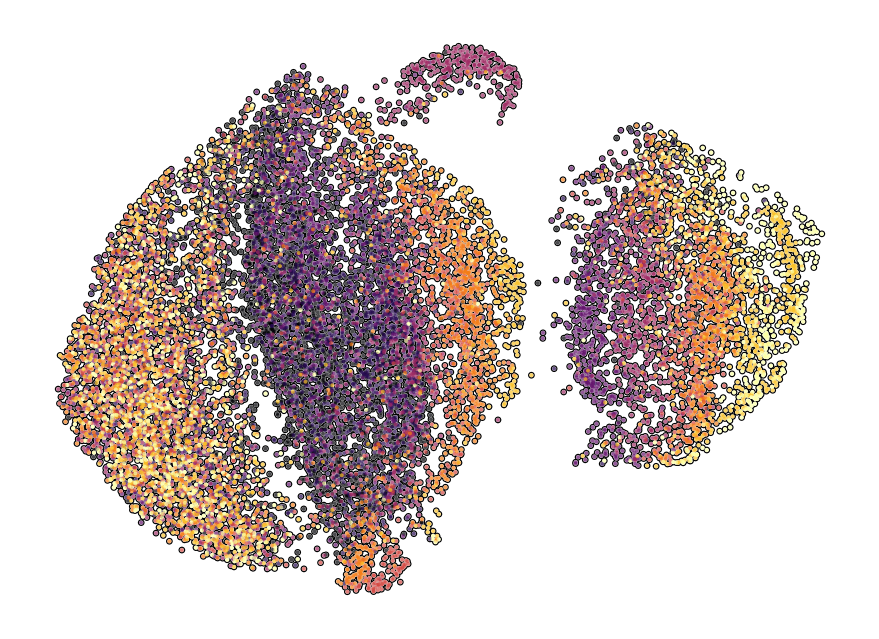

/home/icb/kemal.inecik/tools/apps/mamba/envs/tardis_env/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:371: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
/home/icb/kemal.inecik/tools/apps/mamba/envs/tardis_env/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:381: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
/home/icb/kemal.inecik/tools/apps/mamba/envs/tardis_env/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


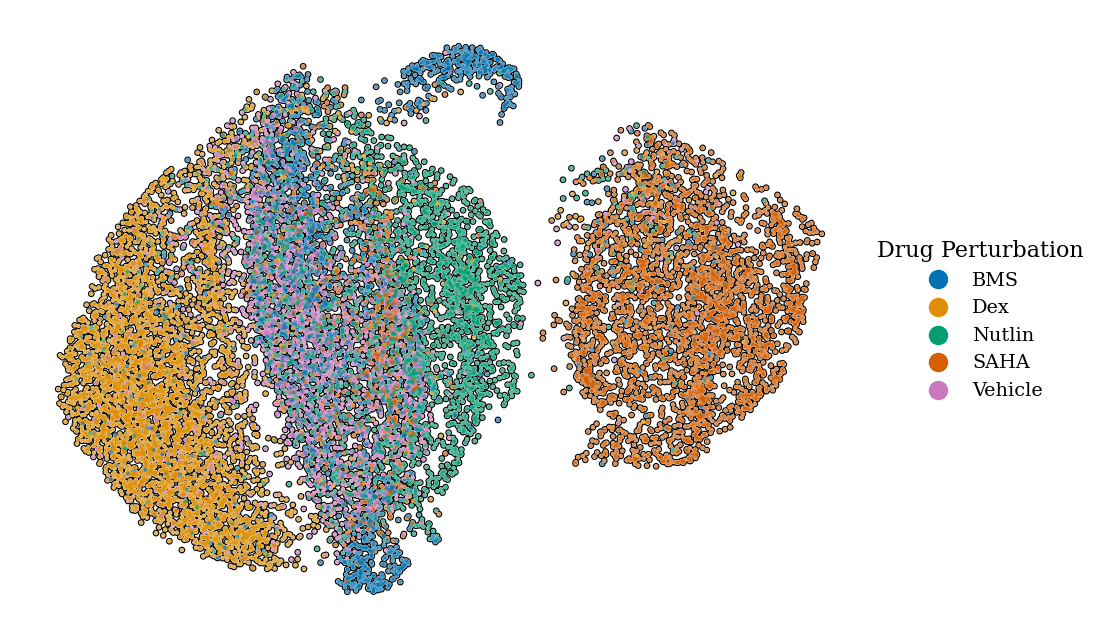

In [49]:
figsize = (7, 5)
fig = plt.figure(figsize=(figsize[0] * 3, figsize[1] * 3))
fig.subplots_adjust(left=0.4, right=0.6, top=0.6, bottom=0.4)

sc.pl.umap(
    latent_pca,
    color=["dose_training"],
    ncols=2,
    frameon=False,
    legend_fontsize="x-small",
    show=False,
    ax=plt.gca(),
    color_map="inferno",
    title="",
    # legend_loc="on data",
    # legend_fontweight="semibold",
    # legend_fontoutline=2,
    add_outline=True,
    colorbar_loc=None
)
plt.show()

figsize = (7, 5)
fig = plt.figure(figsize=(figsize[0] * 3, figsize[1] * 3))
fig.subplots_adjust(left=0.4, right=0.6, top=0.6, bottom=0.4)

sc.pl.umap(
    latent_pca,
    color="condition",
    ncols=2,
    frameon=False,
    palette=sns.color_palette("colorblind"),
    legend_fontsize="x-small",
    show=False,
    ax=plt.gca(),
    title="",
    # legend_loc="on data",
    # legend_fontweight="semibold",
    # legend_fontoutline=2,
    add_outline=True,
)
plt.gca().legend_.set_title("Drug Perturbation", prop={'size':8})
plt.show()

/home/icb/kemal.inecik/tools/apps/mamba/envs/tardis_env/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:371: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  ax.scatter(
/home/icb/kemal.inecik/tools/apps/mamba/envs/tardis_env/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:381: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  ax.scatter(


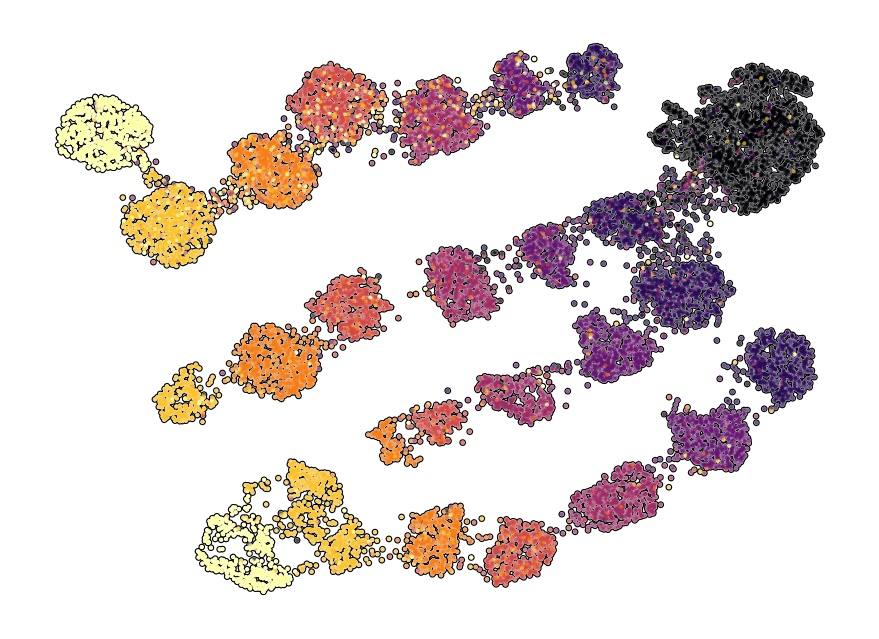

/home/icb/kemal.inecik/tools/apps/mamba/envs/tardis_env/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:371: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
/home/icb/kemal.inecik/tools/apps/mamba/envs/tardis_env/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:381: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
/home/icb/kemal.inecik/tools/apps/mamba/envs/tardis_env/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


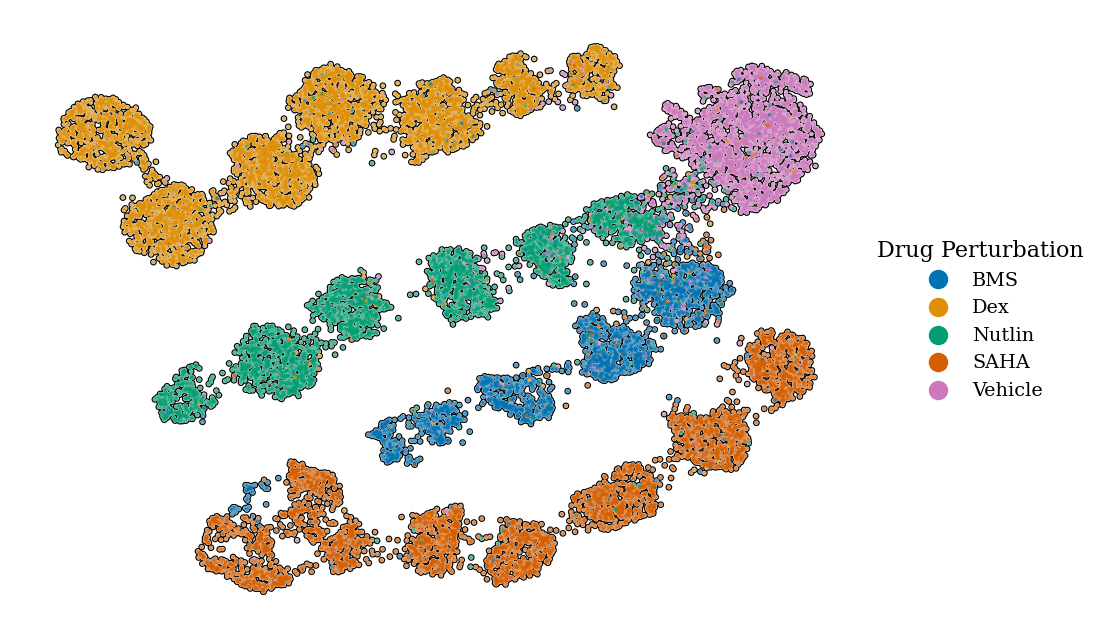

In [50]:
figsize = (7, 5)
fig = plt.figure(figsize=(figsize[0] * 3, figsize[1] * 3))
fig.subplots_adjust(left=0.4, right=0.6, top=0.6, bottom=0.4)

sc.pl.umap(
    latent_tardis,
    color="dose_training",
    ncols=2,
    frameon=False,
    legend_fontsize="x-small",
    show=False,
    ax=plt.gca(),
    color_map="inferno",
    title="",
    # legend_loc="on data",
    # legend_fontweight="semibold",
    # legend_fontoutline=2,
    add_outline=True,
    colorbar_loc=None
)
plt.show()

figsize = (7, 5)
fig = plt.figure(figsize=(figsize[0] * 3, figsize[1] * 3))
fig.subplots_adjust(left=0.4, right=0.6, top=0.6, bottom=0.4)

sc.pl.umap(
    latent_tardis,
    color="condition",
    ncols=2,
    frameon=False,
    palette=sns.color_palette("colorblind"),
    legend_fontsize="x-small",
    show=False,
    ax=plt.gca(),
    title="",
    # legend_loc="on data",
    # legend_fontweight="semibold",
    # legend_fontoutline=2,
    add_outline=True,
)
plt.gca().legend_.set_title("Drug Perturbation", prop={'size':8})
plt.show()